In [1]:
import numpy as np
data = np.random.randn(1000)
data.mean(), data.std()

(np.float64(-0.020501082759088334), np.float64(1.0257312635068563))

In [4]:
%timeit np.random.randn(1000).mean()

16.7 μs ± 172 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [5]:
%%time
data = np.random.randn(10_000_000)
result = data.mean()
print(f"Mean: {result:.6f}")

Mean: 0.000054
CPU times: user 164 ms, sys: 29.8 ms, total: 194 ms
Wall time: 181 ms


$E = mc^2$

In [8]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# генерируем данные
X = torch.randn(1000, 10)
y = (X[:, 0] + X[:, 1] > 0).float()

# разбиваем на train/test
X_train, X_test = X[:800], X[800:]
y_train, y_test = y[:800], y[800:]

# модель
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

dataset = TensorDataset(X_train, y_train.unsqueeze(1))
loader = DataLoader(dataset, batch_size=32)

In [9]:
%%time
for epoch in range(10):
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 | loss: {total_loss/len(loader):.4f}")

Epoch 1/10 | loss: 0.5045
Epoch 2/10 | loss: 0.1199
Epoch 3/10 | loss: 0.0611
Epoch 4/10 | loss: 0.0439
Epoch 5/10 | loss: 0.0252
Epoch 6/10 | loss: 0.0161
Epoch 7/10 | loss: 0.0097
Epoch 8/10 | loss: 0.0073
Epoch 9/10 | loss: 0.0067
Epoch 10/10 | loss: 0.0098
CPU times: user 172 ms, sys: 32.2 ms, total: 204 ms
Wall time: 1.59 s


In [10]:
%%time
# переносим на GPU
model_gpu = model.to("cuda")
X_train_gpu = X_train.to("cuda")
y_train_gpu = y_train.to("cuda")

dataset_gpu = TensorDataset(X_train_gpu, y_train_gpu.unsqueeze(1))
loader_gpu = DataLoader(dataset_gpu, batch_size=32)

optimizer_gpu = torch.optim.Adam(model_gpu.parameters(), lr=0.01)

for epoch in range(10):
    total_loss = 0
    for xb, yb in loader_gpu:
        pred = model_gpu(xb)
        loss = loss_fn(pred, yb)
        optimizer_gpu.zero_grad()
        loss.backward()
        optimizer_gpu.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 | loss: {total_loss/len(loader_gpu):.4f}")

Epoch 1/10 | loss: 0.0176
Epoch 2/10 | loss: 0.0159
Epoch 3/10 | loss: 0.0182
Epoch 4/10 | loss: 0.0079
Epoch 5/10 | loss: 0.0162
Epoch 6/10 | loss: 0.0179
Epoch 7/10 | loss: 0.0226
Epoch 8/10 | loss: 0.0135
Epoch 9/10 | loss: 0.0257
Epoch 10/10 | loss: 0.0130
CPU times: user 381 ms, sys: 480 ms, total: 861 ms
Wall time: 2.37 s


In [11]:
with torch.no_grad():
    preds = (model_gpu(X_test.to("cuda")) > 0.5).float()
    accuracy = (preds.squeeze() == y_test.to("cuda")).float().mean()
    print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.00%


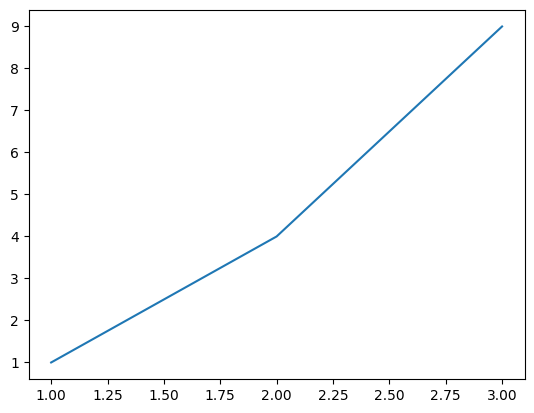

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot([1,2,3], [1,4,9])
plt.show()

In [13]:
!uv pip install scikit-learn

Using Python 3.12.13 environment at: /home/axenick/myproject/.venv
Resolved 5 packages in 1.92s                                         
Prepared 4 packages in 51.25s                                            
Installed 4 packages in 33ms                                
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


In [19]:
%env CUDA_VISIBLE_DEVICES=0
%env CUDA_VISIBLE_DEVICES

env: CUDA_VISIBLE_DEVICES=0


'0'

In [21]:
!uv pip install pandas

Using Python 3.12.13 environment at: /home/axenick/myproject/.venv
Resolved 4 packages in 1.22s                                         
Prepared 1 package in 7.34s                                              
Installed 1 package in 30ms                                 
 + pandas==3.0.3


In [1]:
import pandas as pd

df = pd.DataFrame({
    "model": ["Linear", "Random Forest", "Neural Net"],
    "accuracy": [0.72, 0.89, 0.94],
    "training_time": [0.1, 2.3, 45.6]
})
df

,model,accuracy,training_time
0,Linear,0.72,0.1
1,Random Forest,0.89,2.3
2,Neural Net,0.94,45.6


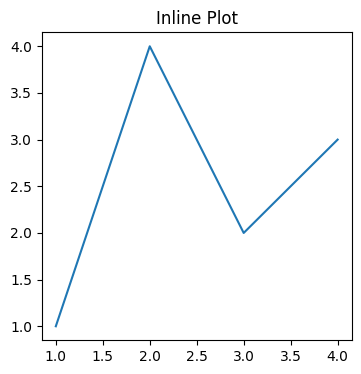

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])
plt.title("Inline Plot")
plt.show()

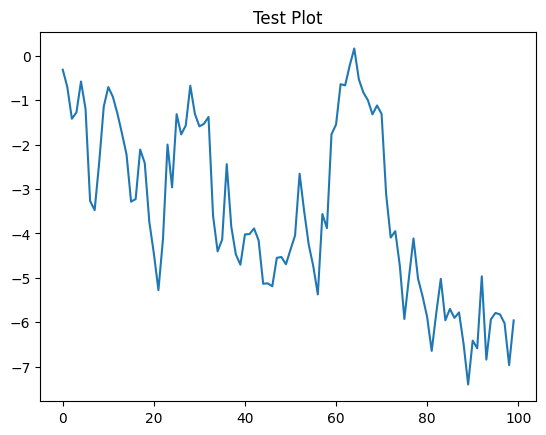

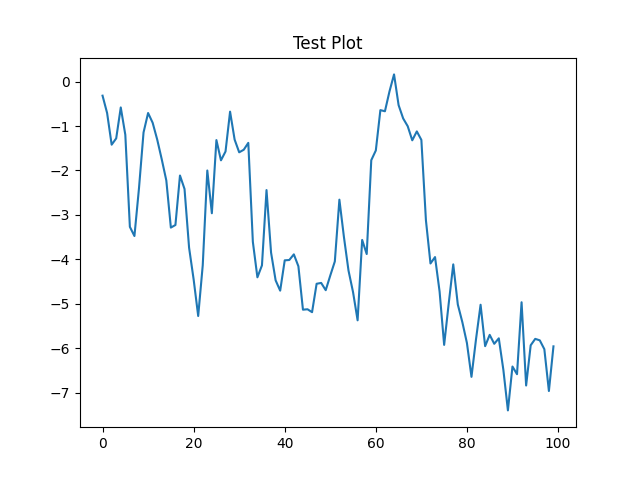

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
ax.plot(np.random.randn(100).cumsum())
ax.set_title("Test Plot")
plt.savefig("architecture.png")
plt.show()
from IPython.display import Image, display
display(Image(filename="architecture.png"))